In [1]:
#EDSL has a cache directory that stores the responses from the LLM. Since we need new responses everytime, we need to clear the cache.    
import shutil
import os

# Path to the .edsl_cache directory
cache_dir = '.edsl_cache'

# Check if the directory exists
if os.path.exists(cache_dir):
    # Remove the directory and its contents
    shutil.rmtree(cache_dir)

In [2]:
from edsl import (
    QuestionFreeText,
    QuestionMultipleChoice,
    QuestionNumerical,
    Scenario,
    Survey,
    Agent,
    AgentList,
    Model,
)
import os
import random
import csv
import pandas as pd
import goodfire

In [3]:
# Initialize Goodfire client
client = goodfire.Client(os.getenv("GOODFIRE_API_KEY"))
# Create a Goodfire variant object instead of just using a string
base_variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

In [4]:
# Base Experiment Class
class SocialExperiment:
    def __init__(self, name, agents, model):
        self.name = name
        self.agents = agents
        self.model = model
        self.questions = []
        self.variant = goodfire.Variant(
            "meta-llama/Llama-3.3-70B-Instruct"
        )  # Initialize with base variant

    def setup(self):
        """Sets up the experiment by defining questions."""
        raise NotImplementedError

    def run(self, intervention=True, use_lite=False):
        """Runs the experiment, optionally applying Goodfire interventions."""
        if intervention:
            # Choose which intervention to use
            if use_lite and hasattr(self, 'get_lite_intervention'):
                controller_json = self.get_lite_intervention()
            else:
                controller_json = self.get_intervention()
            
            self.model.parameters["controller"] = controller_json
            # For feature inspection, we need to apply the same controller to our variant
            self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

            # Extract and apply features from controller JSON
            if "interventions" in controller_json:
                for intervention in controller_json["interventions"]:
                    if (
                        "features" in intervention
                        and "features" in intervention["features"]
                    ):
                        for feature_data in intervention["features"]["features"]:
                            # Create a feature object using feature search instead of direct creation
                            # This avoids needing to provide the index_in_sae
                            features = client.features.search(
                                feature_data["label"], model=self.variant, top_k=1
                            )
                            if features:
                                # Apply the feature with its value
                                self.variant.set(features[0], intervention["value"])
        else:
            self.model.parameters["controller"] = {}
            # Reset variant to base
            self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

        survey = Survey(self.questions)
        results = survey.by(self.agents).by(self.model).run(cache = False)
        return results

    def get_intervention(self):
        """Defines the Goodfire interventions for the experiment."""
        raise NotImplementedError

    def save_results(self, results, filename):
        """Saves results to a CSV file."""
        results.to_csv(filename)

    def print_results(self, results, experiment_name):
        """Prints formatted results for the experiment."""
        print(f"\n{experiment_name} Results:")
        print("--------------------")
        for question in self.questions:
            question_name = question.question_name
            ans = results.select(f"answer.{question_name}")
            com = results.select(f"comment.{question_name}_comment")
            print(f"\nQuestion: {question_name}")
            print(f"Answer: {ans}\nComment: {com}")

    def get_feature_activations(self, results, scenario_name, use_base_variant=False, activations_file=None):
        """Analyze feature activation for results and store in structured text file"""
        print(f"\n--- {scenario_name} Feature Activation ---")

        # Use base variant if requested (for baseline analysis)
        inspect_variant = base_variant if use_base_variant else self.variant

        # Get all question names from the result
        question_names = []
        for column in results.columns:
            if column.startswith("answer."):
                question_name = column.split(".")[1]
                if question_name not in question_names:
                    question_names.append(question_name)

        # Initialize activations data structure
        activations_data = {
            "scenario": scenario_name,
            "variant": "base" if use_base_variant else "intervention",
            "questions": {}
        }

        # Process each question
        for question_name in question_names:
            print(f"\nQuestion: {question_name}")

            # Get the user prompts and model responses
            try:
                # Select the relevant columns
                user_prompts = results.select(f"prompt.{question_name}_user_prompt")
                model_responses = results.select(
                    f"generated_tokens.{question_name}_generated_tokens"
                )

                # Convert to lists
                user_prompt_list = user_prompts.to_list()
                model_response_list = model_responses.to_list()

                # Check if we have data
                if user_prompt_list and model_response_list:
                    question_data = {
                        "total_responses": len(user_prompt_list),
                        "responses": []
                    }
                    
                    # Process ALL examples (no limit)
                    for i, (user_prompt, model_response) in enumerate(
                        zip(user_prompt_list, model_response_list)
                    ):
                        if user_prompt and model_response:
                            # Convert the user prompt from dict to string if necessary
                            if isinstance(user_prompt, dict) and "text" in user_prompt:
                                user_prompt = user_prompt["text"]

                            response_data = {
                                "response_id": i + 1,
                                "user_prompt": str(user_prompt),
                                "model_response": str(model_response),
                                "feature_activations": []
                            }

                            # Inspect feature activation
                            try:
                                inspector = client.features.inspect(
                                    [
                                        {"role": "user", "content": str(user_prompt)},
                                        {
                                            "role": "assistant",
                                            "content": str(model_response),
                                        },
                                    ],
                                    model=inspect_variant,  # Use the appropriate variant
                                )

                                # Store top activated features
                                for activation in inspector.top(k=10):
                                    response_data["feature_activations"].append({
                                        "feature_label": activation.feature.label,
                                        "activation_value": activation.activation
                                    })
                                    
                            except Exception as e:
                                response_data["error"] = f"Error analyzing features: {e}"
                            
                            question_data["responses"].append(response_data)
                    
                    activations_data["questions"][question_name] = question_data
                else:
                    print(f"No data found for question {question_name}")
            except Exception as e:
                print(f"Error processing data for question {question_name}: {e}")

        # Write activations to structured text file
        if activations_file:
            self._write_activations_to_file(activations_data, activations_file)

    def _write_activations_to_file(self, activations_data, filepath):
        """Write activations data to a structured text file"""
        with open(filepath, 'a', encoding='utf-8') as f:
            f.write(f"\n{'='*80}\n")
            f.write(f"SCENARIO: {activations_data['scenario']}\n")
            f.write(f"VARIANT: {activations_data['variant']}\n")
            f.write(f"{'='*80}\n\n")
            
            for question_name, question_data in activations_data['questions'].items():
                f.write(f"QUESTION: {question_name}\n")
                f.write(f"Total Responses: {question_data['total_responses']}\n")
                f.write(f"{'-'*60}\n\n")
                
                for response in question_data['responses']:
                    f.write(f"Response {response['response_id']}:\n")
                    f.write(f"User Prompt: {response['user_prompt']}\n")
                    f.write(f"Model Response: {response['model_response']}\n")
                    
                    if 'error' in response:
                        f.write(f"Error: {response['error']}\n")
                    else:
                        f.write("Top Feature Activations:\n")
                        for i, activation in enumerate(response['feature_activations'], 1):
                            f.write(f"  {i:2d}. {activation['feature_label']}: {activation['activation_value']:.6f}\n")
                    
                    f.write(f"\n{'-'*40}\n\n")
                
                f.write(f"\n{'='*60}\n\n")



In [5]:
# Safe vs. Risky Choice Experiment
class SafeRiskyChoice(SocialExperiment):
    def __init__(self, name, agents, model, risky_reward=100):
        super().__init__(name, agents, model)
        self.risky_reward = risky_reward
        
    def setup(self):
        self.questions = []
        choice_text = (
            "SAFE VS. RISKY CHOICE GAME\n\n"
            "You must choose between two options:\n"
            f"1. Safe Option: Guaranteed 50 tokens.\n"
            f"2. Risky Option: 50% chance of {self.risky_reward} tokens, 50% chance of 0 tokens.\n\n"
            "Which option do you choose?"
        )
        self.questions.append(
            QuestionMultipleChoice(
                question_name="safe_risky_choice",
                question_text=choice_text,
                question_options=[
                    "Safe Option",
                    "Risky Option",
                ],
            )
        )

    def get_intervention(self):
        """Standard steering with 0.7 and 0.5 values"""
        return {
            "interventions": [
                {
                    "mode": "nudge",
                    "features": {
                        "features": [
                            {
                                "uuid": "7f0e30ffb55c412cacd711909b11e5d0",
                                "label": "Willing to take risks or make sacrifices for a goal",
                                "index_in_sae": 184,
                                "max_activation_strength": 1,
                            }
                        ]
                    },
                    "value": 0.7,
                },
                {
                    "mode": "nudge",
                    "features": {
                        "features": [
                            {
                                "uuid": "b53742bf6f5040e0a8aeba37766335ff",
                                "label": "Executing potentially risky operations that require caution",
                                "index_in_sae": 4237,
                                "max_activation_strength": 1,
                            }
                        ]
                    },
                    "value": 0.5,
                },
            ],
            "scopes": [],
            "name": "controller__44686645",
            "nonzero_strength_threshold": None,
            "min_nudge_entropy": None,
            "max_nudge_entropy": None,
        }
    
    def get_lite_intervention(self):
        """Lite steering with 0.4 and 0.6 values"""
        return {
            "interventions": [
                {
                    "mode": "nudge",
                    "features": {
                        "features": [
                            {
                                "uuid": "7f0e30ffb55c412cacd711909b11e5d0",
                                "label": "Willing to take risks or make sacrifices for a goal",
                                "index_in_sae": 184,
                                "max_activation_strength": 1,
                            }
                        ]
                    },
                    "value": 0.6,
                },
                {
                    "mode": "nudge",
                    "features": {
                        "features": [
                            {
                                "uuid": "b53742bf6f5040e0a8aeba37766335ff",
                                "label": "Executing potentially risky operations that require caution",
                                "index_in_sae": 4237,
                                "max_activation_strength": 1,
                            }
                        ]
                    },
                    "value": 0.4,
                },
            ],
            "scopes": [],
            "name": "controller__44686646",
            "nonzero_strength_threshold": None,
            "min_nudge_entropy": None,
            "max_nudge_entropy": None,
        }



In [6]:
# Baseline agents (no special traits)
dummy_agents = AgentList(
    [
        Agent(name=f"Agent_{i}", traits={"subject_id": f"A{i}"}, instruction="")
        for i, age in enumerate(range(20, 60, 1), start=1)
    ]
)

# Slightly risk-loving agents (with prompting traits)
slightly_risk_agents = AgentList(
    [
        Agent(
            name=f"SlightlyRisk_Agent_{i}", 
            traits={
                "subject_id": f"SR{i}",
                "personality": "slightly likes to take risks",
            }, 
            instruction=""
        )
        for i, age in enumerate(range(20, 60, 1), start=1)
    ]
)

model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")

In [7]:
def run_reward_experiments(baseline_agents, slightly_risk_agents, model, start=10, end=180, step=5, analyze_activations=False):
    results = []
    
    # Create results directory with timestamp
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    results_dir = f"mech_interp_games/safe_risky_choice/results_{timestamp}"
    os.makedirs(results_dir, exist_ok=True)
    
    # Create activations file path and initialize if needed
    activations_file = os.path.join(results_dir, "feature_activations.txt")
    
    # Only create/clear the activations file if analysis is enabled
    if analyze_activations:
        with open(activations_file, 'w', encoding='utf-8') as f:
            f.write("FEATURE ACTIVATIONS LOG\n")
            f.write("=" * 80 + "\n")
            f.write(f"Experiment: Safe vs. Risky Choice (3 Conditions)\n")
            f.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write("=" * 80 + "\n\n")
    
    for reward in range(start, end + step, step):
        print(f"\n--- Running experiment with risky reward: {reward} tokens ---")
        
        # Create experiment with current reward amount
        experiment_name = f"Safe vs. Risky Choice ({reward} tokens)"
        
        # Create fresh model instances for each experiment to avoid controller persistence
        baseline_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        slightly_prompting_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        steering_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        
        # 1. BASELINE: Normal agents, no intervention
        print(f"\nRunning {experiment_name} - BASELINE (normal agents, no intervention)...")
        baseline_experiment = SafeRiskyChoice(experiment_name, baseline_agents, baseline_model, risky_reward=reward)
        baseline_experiment.setup()
        baseline_results = baseline_experiment.run(intervention=False)
        
        # 2. SLIGHTLY RISK PROMPTING: Slightly risk-loving agents, no steering
        print(f"\nRunning {experiment_name} - SLIGHTLY RISK PROMPTING (slightly risk agents, no steering)...")
        slightly_prompting_experiment = SafeRiskyChoice(experiment_name, slightly_risk_agents, slightly_prompting_model, risky_reward=reward)
        slightly_prompting_experiment.setup()
        slightly_prompting_results = slightly_prompting_experiment.run(intervention=False)
        
        # 3. STEERING: Normal agents, with steering intervention (0.7, 0.5)
        print(f"\nRunning {experiment_name} - STEERING (normal agents, steering 0.7/0.5)...")
        steering_experiment = SafeRiskyChoice(experiment_name, baseline_agents, steering_model, risky_reward=reward)
        steering_experiment.setup()
        steering_results = steering_experiment.run(intervention=True, use_lite=False)
        
        # Save results
        baseline_filename = os.path.join(results_dir, f"safe_risky_baseline_{reward}.csv")
        slightly_prompting_filename = os.path.join(results_dir, f"safe_risky_slightly_prompting_{reward}.csv")
        steering_filename = os.path.join(results_dir, f"safe_risky_steering_{reward}.csv")
        
        baseline_experiment.save_results(baseline_results, baseline_filename)
        slightly_prompting_experiment.save_results(slightly_prompting_results, slightly_prompting_filename)
        steering_experiment.save_results(steering_results, steering_filename)
        
        # Print results
        baseline_experiment.print_results(baseline_results, f"{experiment_name} - BASELINE")
        slightly_prompting_experiment.print_results(slightly_prompting_results, f"{experiment_name} - SLIGHTLY PROMPTING")
        steering_experiment.print_results(steering_results, f"{experiment_name} - STEERING")
        
        # Track results for summary
        baseline_choices = baseline_results.select("answer.safe_risky_choice").to_list()
        slightly_prompting_choices = slightly_prompting_results.select("answer.safe_risky_choice").to_list()
        steering_choices = steering_results.select("answer.safe_risky_choice").to_list()
        
        risky_percent_baseline = baseline_choices.count("Risky Option") / len(baseline_choices) * 100 if baseline_choices else 0
        risky_percent_slightly_prompting = slightly_prompting_choices.count("Risky Option") / len(slightly_prompting_choices) * 100 if slightly_prompting_choices else 0
        risky_percent_steering = steering_choices.count("Risky Option") / len(steering_choices) * 100 if steering_choices else 0
        
        results.append({
            "reward": reward,
            "risky_percent_baseline": risky_percent_baseline,
            "risky_percent_slightly_prompting": risky_percent_slightly_prompting,
            "risky_percent_steering": risky_percent_steering
        })

        # Get the prompts and responses for feature inspection (only if enabled)
        if analyze_activations:
            print("\n=== Feature Activation Analysis ===")

            # Analyze baseline feature activation and store in file
            baseline_experiment.get_feature_activations(
                baseline_results, f"Baseline (Reward: {reward})", use_base_variant=True, activations_file=activations_file
            )

            # Analyze slightly prompting feature activation and store in file
            slightly_prompting_experiment.get_feature_activations(
                slightly_prompting_results, f"Slightly Prompting (Reward: {reward})", use_base_variant=True, activations_file=activations_file
            )

            # Analyze steering feature activation and store in file
            steering_experiment.get_feature_activations(
                steering_results, f"Steering (Reward: {reward})", use_base_variant=False, activations_file=activations_file
            )
        else:
            print("\n⏭️  Skipping feature activation analysis (disabled)")

    # Write summary to CSV
    summary_file = os.path.join(results_dir, "reward_experiment_summary.csv")
    with open(summary_file, 'w', newline='') as csvfile:
        fieldnames = ["reward", "risky_percent_baseline", "risky_percent_slightly_prompting", "risky_percent_steering"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)
    
    print(f"\n{'='*80}")
    print(f"✓ Results summary saved to {summary_file}")
    if analyze_activations:
        print(f"✓ Feature activations saved to {activations_file}")
    else:
        print(f"⏭️  Feature activations not collected (disabled)")
    print(f"{'='*80}")
    return results



## Run Experiments

**Feature Activation Analysis Control:**
- Set `analyze_activations=True` to collect detailed feature activations (slower, good for analysis)
- Set `analyze_activations=False` to skip activations (faster, good for quick runs)

This can significantly speed up your experiments when you just need the choice data without activation analysis.


In [ ]:
# Run the reward experiments
# Set analyze_activations=True to collect feature activations (slower)
# Set analyze_activations=False to skip activations (faster)
results_summary = run_reward_experiments(
    dummy_agents, 
    slightly_risk_agents, 
    model,
    analyze_activations=True  # Toggle this: True to collect activations, False to skip
)


--- Running experiment with risky reward: 10 tokens ---

Running Safe vs. Risky Choice (10 tokens) - BASELINE (normal agents, no intervention)...

Running Safe vs. Risky Choice (10 tokens) - SLIGHTLY RISK PROMPTING (slightly risk agents, no steering)...

Running Safe vs. Risky Choice (10 tokens) - STEERING (normal agents, steering 0.7/0.5)...

Safe vs. Risky Choice (10 tokens) - BASELINE Results:
--------------------

Question: safe_risky_choice
Answer: Dataset([{'answer.safe_risky_choice': ['Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe O

Using most recent results directory: mech_interp_games/safe_risky_choice/results_20251018_133805


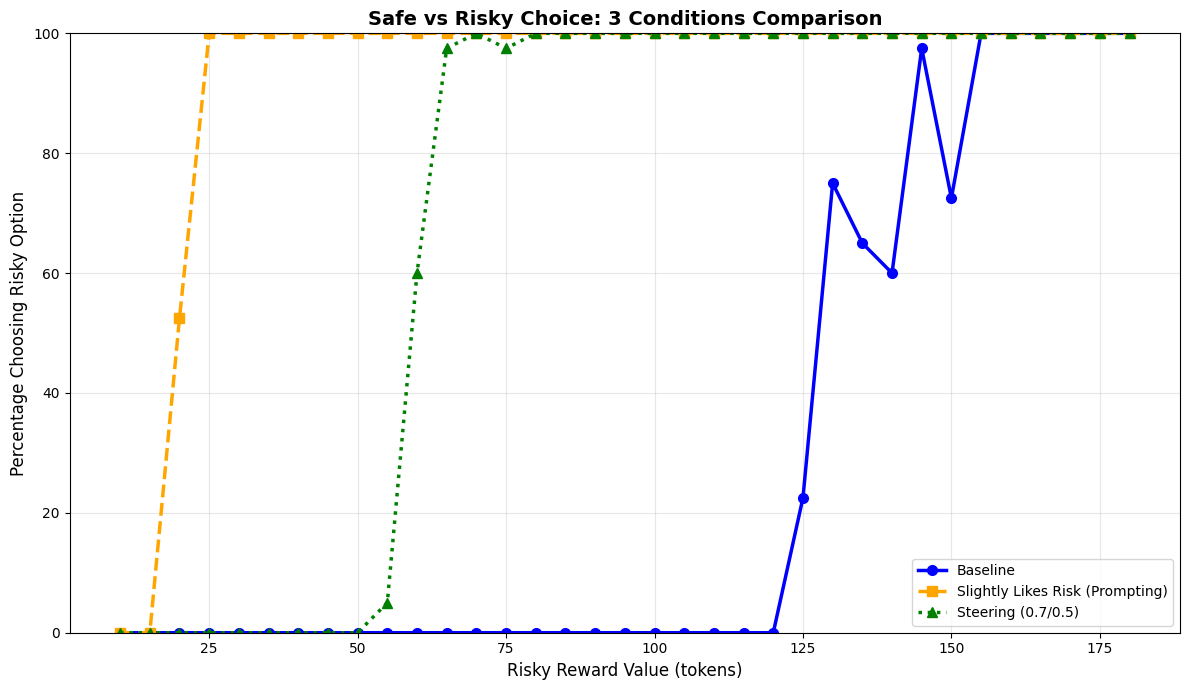

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_safe_risky_choices(directory=None):
    # If no directory specified, find the most recent results folder
    if directory is None:
        base_dir = "mech_interp_games/safe_risky_choice"
        if os.path.exists(base_dir):
            # Find all results directories with timestamps
            results_dirs = [d for d in os.listdir(base_dir) if d.startswith("results_")]
            if results_dirs:
                # Sort by timestamp (newest first)
                results_dirs.sort(reverse=True)
                directory = os.path.join(base_dir, results_dirs[0])
                print(f"Using most recent results directory: {directory}")
            else:
                print("No results directories found!")
                return
        else:
            print("Base directory not found!")
            return
    
    # Identify all relevant files
    files = sorted([f for f in os.listdir(directory) if f.startswith("safe_risky_") and f.endswith(".csv")])

    # Data storage for three conditions
    baseline_data = {}
    slightly_prompting_data = {}
    steering_data = {}

    # Process each file
    for file in files:
        file_path = os.path.join(directory, file)
        df = pd.read_csv(file_path)
        
        # Compute percentage of "Risky Option"
        total_choices = len(df)
        risky_count = (df["answer.safe_risky_choice"] == "Risky Option").sum()
        risky_percentage = (risky_count / total_choices) * 100
        
        # Extract iteration number from filename
        iteration = int(file.split("_")[-1].split(".")[0])
        
        # Store in appropriate dictionary based on condition
        if "baseline" in file:
            baseline_data[iteration] = risky_percentage
        elif "slightly_prompting" in file:
            slightly_prompting_data[iteration] = risky_percentage
        elif "steering" in file:
            steering_data[iteration] = risky_percentage

    # Sort by iteration number
    baseline_data = dict(sorted(baseline_data.items()))
    slightly_prompting_data = dict(sorted(slightly_prompting_data.items()))
    steering_data = dict(sorted(steering_data.items()))

    # Create simple plot
    plt.figure(figsize=(12, 7))
    
    # Plot the three conditions
    plt.plot(baseline_data.keys(), baseline_data.values(), 
             marker="o", linestyle="-", linewidth=2.5, markersize=7,
             label="Baseline", color='blue')
    
    plt.plot(slightly_prompting_data.keys(), slightly_prompting_data.values(), 
             marker="s", linestyle="--", linewidth=2.5, markersize=7,
             label="Slightly Likes Risk (Prompting)", color='orange')
    
    plt.plot(steering_data.keys(), steering_data.values(), 
             marker="^", linestyle=":", linewidth=2.5, markersize=7,
             label="Steering (0.7/0.5)", color='green')

    plt.xlabel("Risky Reward Value (tokens)", fontsize=12)
    plt.ylabel("Percentage Choosing Risky Option", fontsize=12)
    plt.title("Safe vs Risky Choice: 3 Conditions Comparison", fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    
    plt.tight_layout()
    plt.show()

# Example usage:
plot_safe_risky_choices()  # Automatically uses the most recent results directory


Using most recent results directory: mech_interp_games/safe_risky_choice/results_20251018_133805


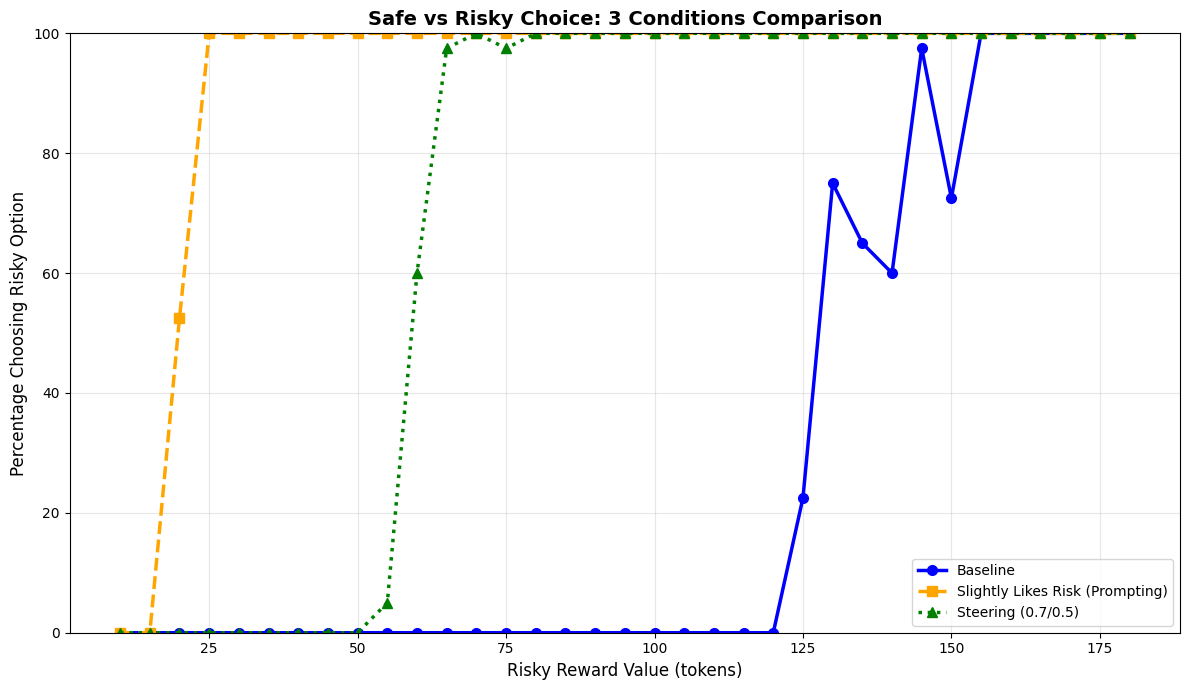

In [10]:
# Plot the results after running experiments
plot_safe_risky_choices()  # Automatically uses the most recent results directory
